In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import os
from scipy.stats import uniform, norm, multivariate_normal
import seaborn as sns 
import multiprocessing as mp
from functools import partial
import time
import copy
import glob
import warnings
warnings.filterwarnings('ignore')

from agent_based_model import load_data, preprocess_data, \
                                set_initial_values, main_function
from main_pool import Main
from calibr_funcs import plot_results
#from hybrid_abm_to_seir import ABC_Agent, generate_synthetic_data

from hybrid_network_to_seir import NetworkSEIR_tuned,\
                                    generate_synthetic_data


import plot_hyb
import predict_Beta_I
import seir_discrete
import choice_start_day

%load_ext autoreload
%autoreload 2

plt.style.use("default")

In [4]:
# generate synthetic data with known parameters for testing
true_tau = 0.04
true_alpha = 0.8

days=range(1, 250)
data_p = 'new_network_check/'
'''
observed_data = generate_synthetic_data(alpha=true_alpha, lmbd=true_lmbd, 
                                        days=days, data_path=data_p,
                                       with_seirb=True, with_switch=False,
                                       for_observed=True)
'''
observed_data = pd.read_csv(f'results/{data_p}/observed.csv')

<Axes: >

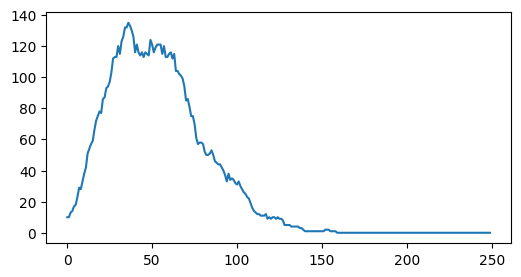

In [5]:
plt.subplots(figsize=(6,3))
observed_data.I.plot()

## History Matching

In [30]:
# create
network_params = {'n_nodes': 1000,
                  'network_type': 'ba'}
observed_prv = observed_data[['I']]
hn = NetworkSEIR_tuned(observed_prv, network_params,
                       fixed_sigma=0.1, fixed_gamma=0.08)

'''
true_tau = 0.04
true_alpha = 0.8
'''
# define parameter ranges for priors
prior_ranges = {"tau": (0.01, 0.1),  
                "alpha": (0.5, 1.) 
                }

start_time = time.time()
# run History Matching
hm_results = hn.history_matching(prior_ranges, n_samples=200,
                                 adaptive=True, accept_ratio=0.1,
                                 prepared=False)
end_time = time.time()

print('It took: ', end_time - start_time)

Network SEIR - Fixed parameters: sigma = 0.1, gamma = 0.08
Calibrating parameters: tau (transmission rate), rho (initial infection fraction)
Running Network SEIR history matching with 200 samples...


100%|██████████| 200/200 [00:30<00:00,  6.57it/s]

Accepted 20 parameter sets
It took:  30.44689679145813


In [31]:
hm_results.iloc[:10]

,tau,alpha,distance,trajectory
66,0.036016,0.837265,21.497992,0 10.0 1 10.0 2 9.0 3 11....
20,0.082318,0.711691,24.883534,0 10.0 1 9.0 2 12.0 3 13....
44,0.044867,0.788334,39.718876,0 10.0 1 10.0 2 10.0 3 14....
137,0.024440,0.896364,50.028112,0 10.0 1 11.0 2 13.0 3 15....
68,0.064140,0.712667,66.791165,0 10.0 1 10.0 2 12.0 3 13....
46,0.070163,0.701625,85.566265,0 10.0 1 9.0 2 8.0 3 9....
177,0.084046,0.672334,94.638554,0 10.0 1 7.0 2 11.0 3 14....
43,0.068735,0.688541,98.441767,0 10.0 1 9.0 2 11.0 3 12....
182,0.027002,0.915373,100.534137,0 10.0 1 9.0 2 9.0 3 11....
17,0.055634,0.697420,124.000000,0 10.0 1 9.0 2 8.0 3 10....


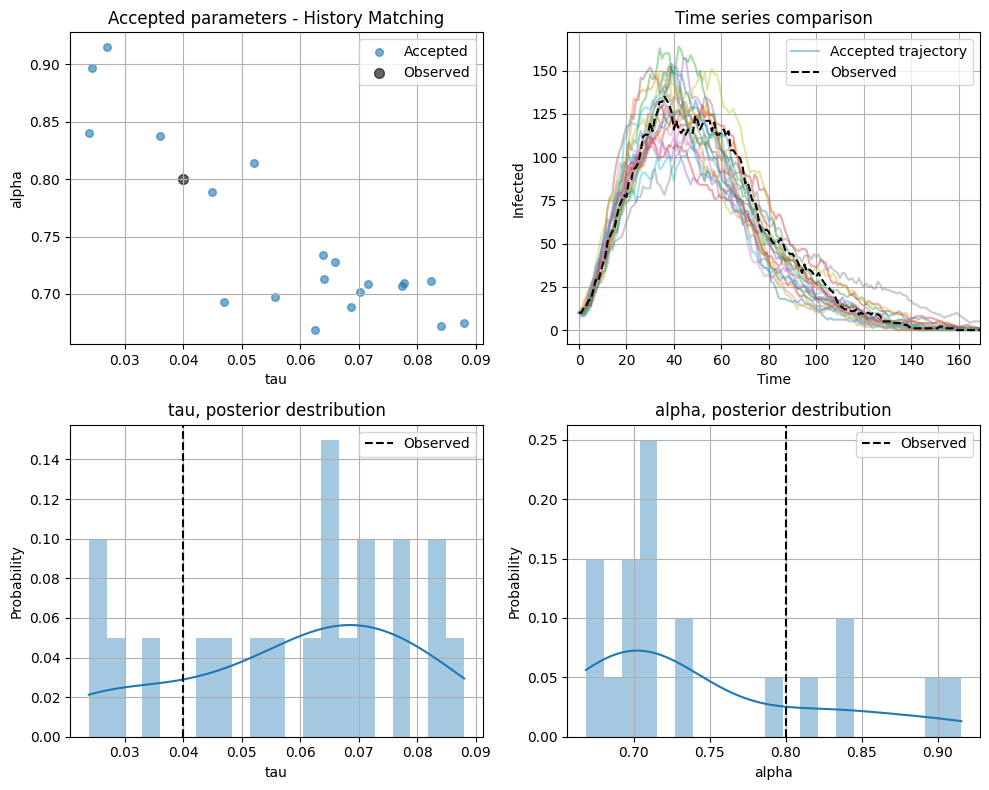

In [32]:
plot_results(observed_prv, hm_results, 
             "History Matching", n_trajectories=len(hm_results),
             true_p0=true_tau, true_p1=true_alpha)

In [33]:
hm_results['distance'].quantile(0.9)

np.float64(184.09598393574296)

In [40]:
# в ответе дистанция не соответствует траектории

'''
n_particles -- how many samples to choose from prior
n_populations -- ~number of chains
frac -- switch when fraction of Infected > <frac>
num_runs -- how many trajectories to generate for each param value
'''
start_time = time.time()
smc_results = hn.smc_abc(n_particles=10, n_populations=1, 
                         frac=0.05, num_runs=5, with_switch=True, 
                         method='expanding')

end_time = time.time()
print('It took: ', end_time - start_time)

Running ABC-SMC with 1 populations...
SMC Population 1/1, epsilon = 184.10


SMC Population 1: 100%|██████████| 10/10 [00:06<00:00,  1.53it/s]

Effective sample size: 1.0
[{'tau': np.float64(0.06256619163991285), 'alpha': np.float64(0.6685888150802943)}, {'tau': np.float64(0.08231832615305512), 'alpha': np.float64(0.711691302798305)}, {'tau': np.float64(0.08801451332045909), 'alpha': np.float64(0.6745501375877667)}, {'tau': np.float64(0.03601551071133342), 'alpha': np.float64(0.8372653279675084)}, {'tau': np.float64(0.02383644814465293), 'alpha': np.float64(0.8401685208646414)}, {'tau': np.float64(0.027002060551651635), 'alpha': np.float64(0.915373034063949)}, {'tau': np.float64(0.02383644814465293), 'alpha': np.float64(0.8401685208646414)}, {'tau': np.float64(0.024439560559100626), 'alpha': np.float64(0.8963635253569555)}, {'tau': np.float64(0.06873489368619222), 'alpha': np.float64(0.688540568860905)}, {'tau': np.float64(0.08404604429499775), 'alpha': np.float64(0.6723342018973402)}]
10 10 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
[{'tau': np.float64(0.027002060551651635), 'alpha': np.float64(0.915373034063949)}, {'tau': np.float64(0.

In [36]:
smc_results

,tau,alpha,weight,distance,trajectory
1,0.065897,0.727997,0.1,233.204819,"[10.0, 9.0, 11.0, 14.0, 16.0, 21.0, 25.0, 32.0..."
9,0.065897,0.727997,0.1,242.538153,"[10.0, 9.0, 11.0, 14.0, 16.0, 21.0, 25.0, 32.0..."
3,0.065897,0.727997,0.1,300.032129,"[10.0, 9.0, 11.0, 14.0, 16.0, 21.0, 25.0, 32.0..."
8,0.065897,0.727997,0.1,309.124498,"[10.0, 9.0, 11.0, 14.0, 16.0, 21.0, 25.0, 32.0..."
0,0.065897,0.727997,0.1,358.710843,"[10.0, 9.0, 11.0, 14.0, 16.0, 21.0, 25.0, 32.0..."
2,0.065897,0.727997,0.1,367.875502,"[10.0, 9.0, 11.0, 14.0, 16.0, 21.0, 25.0, 32.0..."
6,0.065897,0.727997,0.1,455.060241,"[10.0, 9.0, 11.0, 14.0, 16.0, 21.0, 25.0, 32.0..."
5,0.065897,0.727997,0.1,486.172691,"[10.0, 9.0, 11.0, 14.0, 16.0, 21.0, 25.0, 32.0..."
7,0.065897,0.727997,0.1,489.220884,"[10.0, 9.0, 11.0, 14.0, 16.0, 21.0, 25.0, 32.0..."
4,0.065897,0.727997,0.1,554.638554,"[10.0, 9.0, 11.0, 14.0, 16.0, 21.0, 25.0, 32.0..."


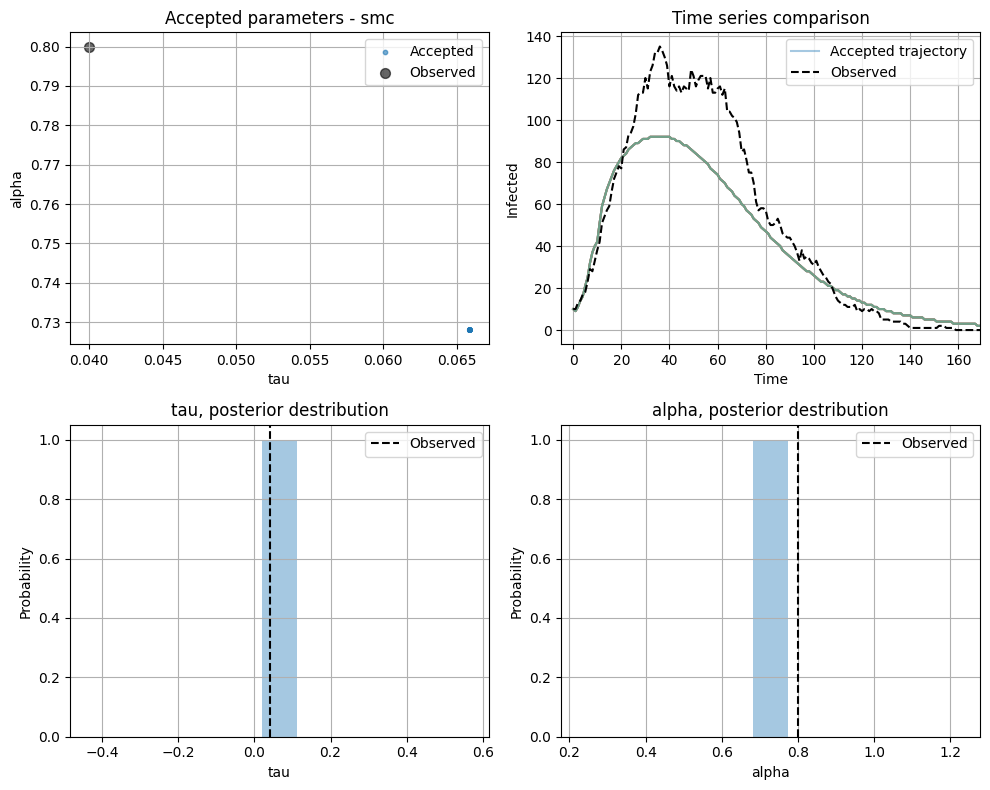

In [38]:
plot_results(observed_prv, smc_results, 
             "smc", n_trajectories=len(smc_results),
             true_p0=true_tau, true_p1=true_alpha)

In [163]:
'''
n_particles -- how many samples to choose from prior
n_populations -- ~number of chains
frac -- switch when fraction of Infected > <frac>
num_runs -- how many trajectories to generate for each param value
'''
smc_results2 = hn.smc_abc(n_particles=200, n_populations=3, 
                          frac=0.05, num_runs=5, with_switch=False)

Running ABC-SMC with 3 populations...
SMC Population 1/3, epsilon = 382.21


SMC Population 1: 100%|██████████| 200/200 [00:50<00:00,  3.95it/s]


Effective sample size: 134.0
SMC Population 2/3, epsilon = 175.81


SMC Population 2: 100%|██████████| 200/200 [00:50<00:00,  3.94it/s]


Effective sample size: 56.0
SMC Population 3/3, epsilon = 80.87


SMC Population 3: 100%|██████████| 200/200 [00:50<00:00,  3.95it/s]

Effective sample size: 23.0
ABC-SMC completed with 200 particles


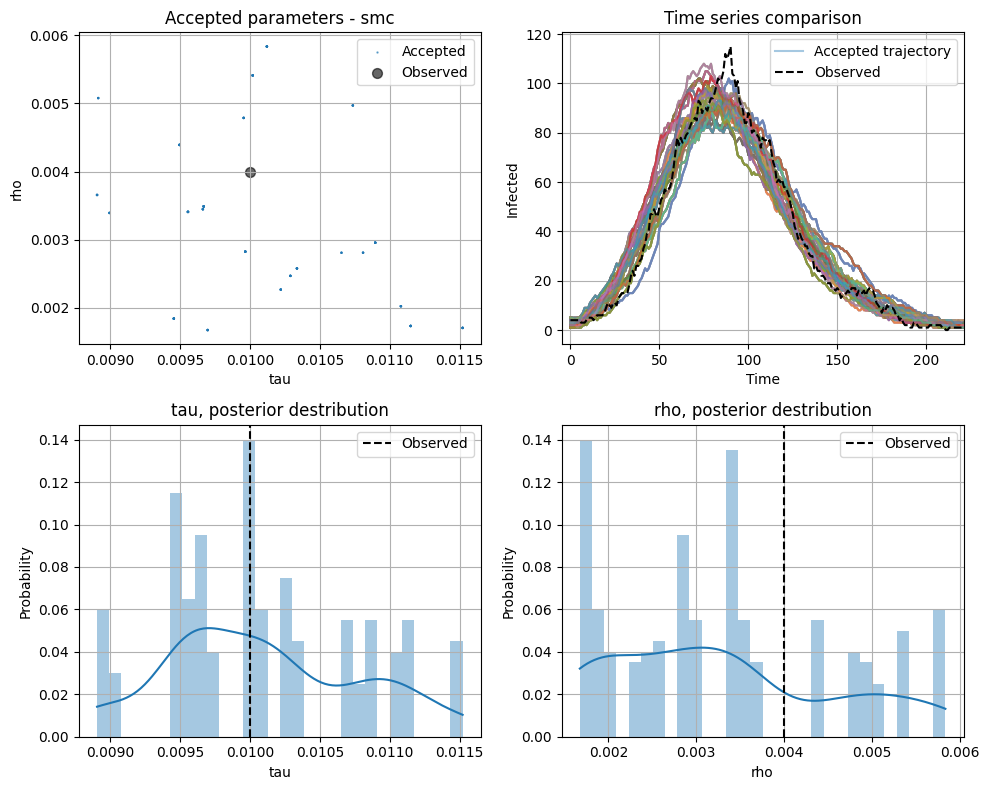

In [164]:
plot_results(observed_prv, smc_results2, 
             "smc", n_trajectories=len(smc_results2),
             true_alpha=true_tau, true_lmbd=true_rho)

In [165]:
# в ответе дистанция не соответствует траектории

'''
n_particles -- how many samples to choose from prior
n_populations -- ~number of chains
frac -- switch when fraction of Infected > <frac>
num_runs -- how many trajectories to generate for each param value
'''
smc_results = hn.smc_abc(n_particles=500, n_populations=5, 
                         frac=0.05, num_runs=5, with_switch=True, 
                         method='expanding')

Running ABC-SMC with 5 populations...
SMC Population 1/5, epsilon = 382.21


SMC Population 1: 100%|██████████| 500/500 [02:19<00:00,  3.59it/s]


Effective sample size: 327.0
SMC Population 2/5, epsilon = 259.22


SMC Population 2: 100%|██████████| 500/500 [02:20<00:00,  3.55it/s]


Effective sample size: 157.0
SMC Population 3/5, epsilon = 175.81


...

Effective sample size: 128.0
SMC Population 4/5, epsilon = 119.24


SMC Population 4: 100%|██████████| 500/500 [02:22<00:00,  3.50it/s]


Effective sample size: 45.0
SMC Population 5/5, epsilon = 80.87


SMC Population 5: 100%|██████████| 500/500 [02:22<00:00,  3.50it/s]

Effective sample size: 1.0
ABC-SMC completed with 500 particles


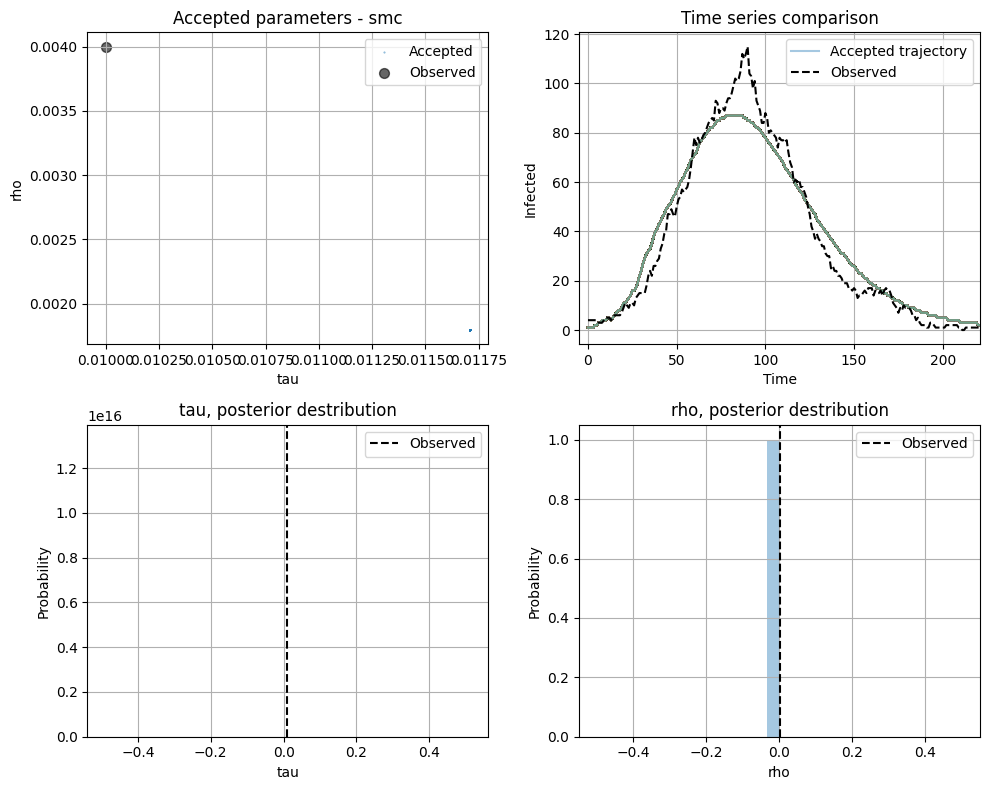

In [166]:
plot_results(observed_prv, smc_results, 
             "smc", n_trajectories=len(smc_results),
             true_alpha=true_tau, true_lmbd=true_rho)

In [167]:
'''
n_particles -- how many samples to choose from prior
n_populations -- ~number of chains
frac -- switch when fraction of Infected > <frac>
num_runs -- how many trajectories to generate for each param value
'''
smc_results2 = hn.smc_abc(n_particles=500, n_populations=5, 
                          frac=0.05, num_runs=5, with_switch=False)

Running ABC-SMC with 5 populations...
SMC Population 1/5, epsilon = 382.21


SMC Population 1: 100%|██████████| 500/500 [02:06<00:00,  3.96it/s]


Effective sample size: 326.0
SMC Population 2/5, epsilon = 259.22


SMC Population 2: 100%|██████████| 500/500 [02:06<00:00,  3.96it/s]


Effective sample size: 209.0
SMC Population 3/5, epsilon = 175.81


...

Effective sample size: 201.0
SMC Population 4/5, epsilon = 119.24


SMC Population 4: 100%|██████████| 500/500 [02:08<00:00,  3.89it/s]


Effective sample size: 106.0
SMC Population 5/5, epsilon = 80.87


SMC Population 5: 100%|██████████| 500/500 [02:10<00:00,  3.84it/s]

Effective sample size: 68.0
ABC-SMC completed with 500 particles


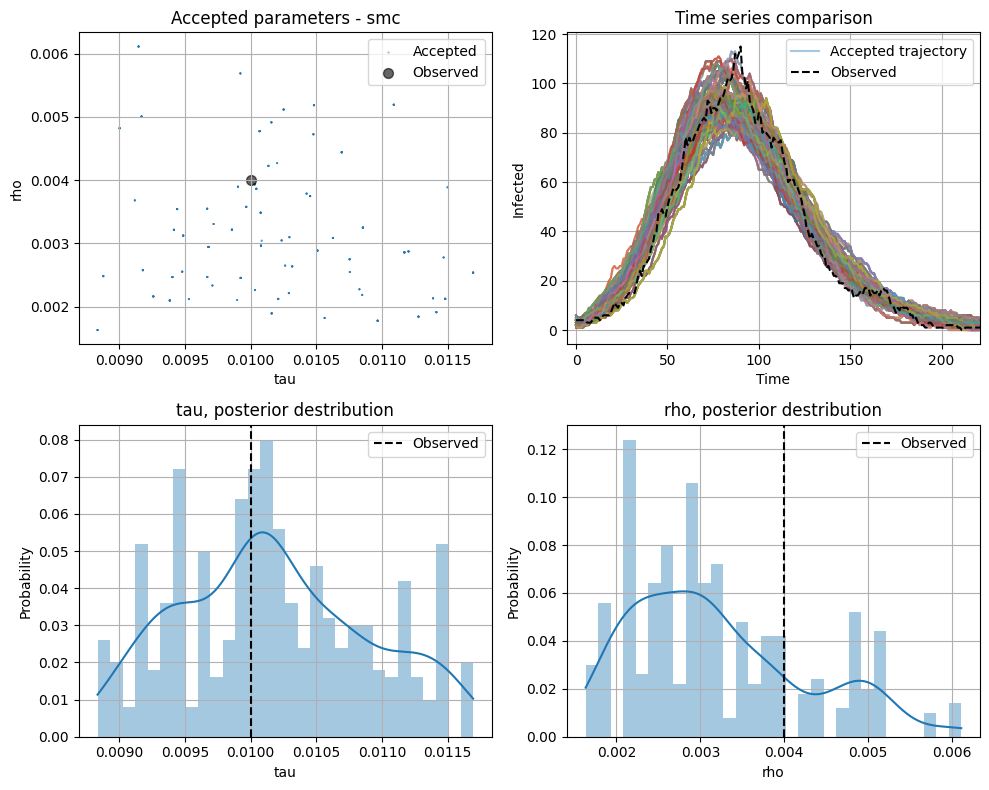

In [168]:
plot_results(observed_prv, smc_results2, 
             "smc", n_trajectories=len(smc_results2),
             true_alpha=true_tau, true_lmbd=true_rho)

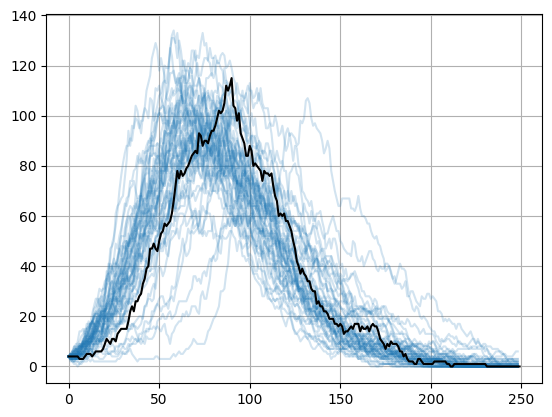

In [158]:
for i in range(50):
    r = hn.simulator_function(tau=0.01, rho=0.004, 
                       with_switch=False, num_runs=1, frac=0.05)
    plt.plot(r['I'], color='tab:blue', alpha=0.2)

plt.plot(observed_prv, color='black')
plt.grid()

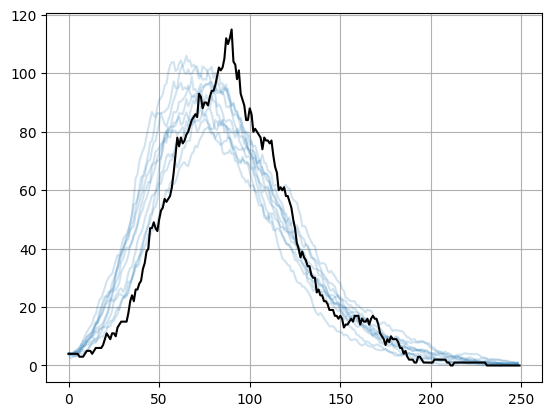

In [45]:
for i in range(10):
    r = hn.simulator_function(tau=0.01, rho=0.004, 
                       with_switch=False, num_runs=5, frac=0.05)
    plt.plot(r['I'], color='tab:blue', alpha=0.2)

plt.plot(observed_prv, color='black')
plt.grid()

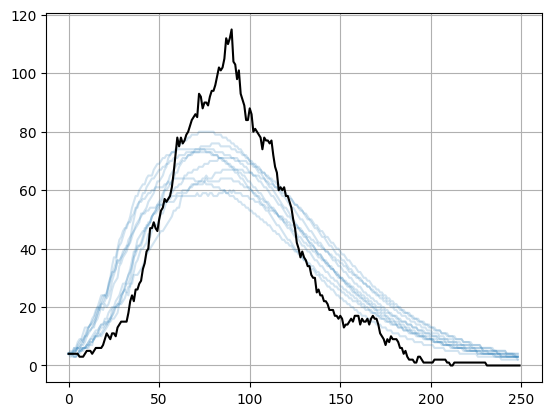

In [159]:
for i in range(10):
    r = hn.simulator_function(tau=0.01, rho=0.004, 
                              with_switch=True, num_runs=5, frac=0.05, 
                              method='expanding')
    plt.plot(r['I'], color='tab:blue', alpha=0.2)

plt.plot(observed_prv, color='black')
plt.grid()

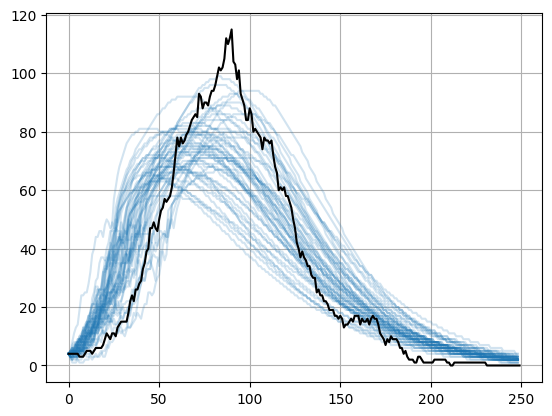

In [160]:
for i in range(50):
    r = hn.simulator_function(tau=0.01, rho=0.004, 
                              with_switch=True, num_runs=1, frac=0.05, 
                              method='expanding')
    plt.plot(r['I'], color='tab:blue', alpha=0.2)

plt.plot(observed_prv, color='black')
plt.grid()

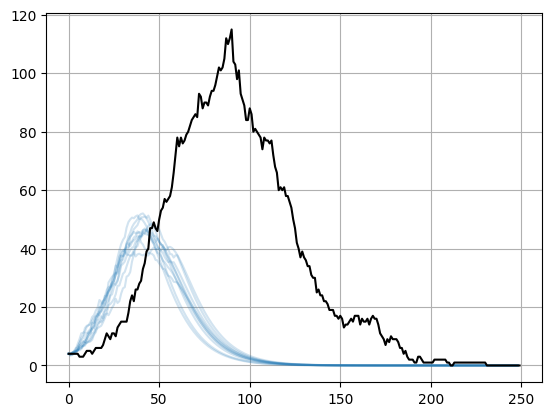

In [24]:
for i in range(10):
    r = hn.simulator_function(tau=0.01, rho=0.004, 
                              with_switch=True, num_runs=5, frac=0.05, 
                              method='last')
    plt.plot(r['I'], color='tab:blue', alpha=0.2)

plt.plot(observed_prv, color='black')
plt.grid()

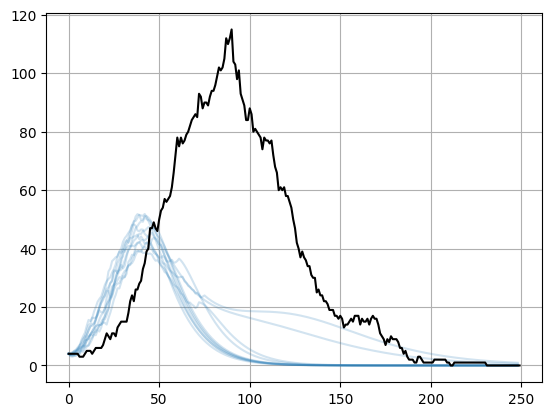

In [22]:
for i in range(10):
    r = hn.simulator_function(tau=0.01, rho=0.004, 
                              with_switch=True, num_runs=5, frac=0.05, 
                              method='rolling')
    plt.plot(r['I'], color='tab:blue', alpha=0.2)

plt.plot(observed_prv, color='black')
plt.grid()

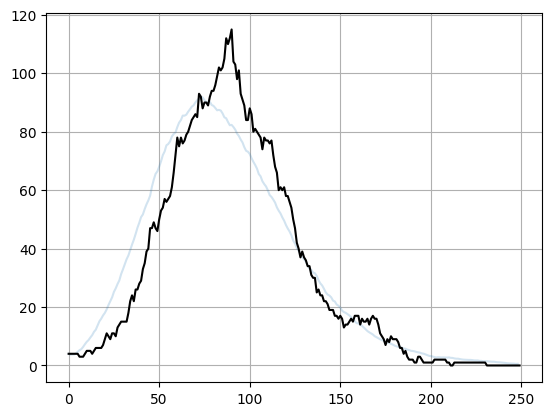

In [119]:
r = hn.simulator_function(tau=0.01, rho=0.004, 
                       with_switch=False, num_runs=50, frac=0.02)
plt.plot(r['I'], color='tab:blue', alpha=0.2)

plt.plot(observed_prv, color='black')
plt.grid()